# 단변수 데이터 분석

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import platform

if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='DejaVu Sans')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('NumPy 버전:', np.__version__)
print('환경 설정 완료')

NumPy 버전: 2.3.5
환경 설정 완료


In [7]:
import pandas as pd

### 1. 범주형 데이터

In [8]:
season = pd.Series(['봄', '여름', '가을', '겨울', '봄', '봄', '여름', '가을'])
season

0     봄
1    여름
2    가을
3    겨울
4     봄
5     봄
6    여름
7    가을
dtype: object

In [9]:
season.value_counts()

봄     3
여름    2
가을    2
겨울    1
Name: count, dtype: int64

In [11]:
# 비율 계산
(season.value_counts() / season.size).round(2)

봄     0.38
여름    0.25
가을    0.25
겨울    0.12
Name: count, dtype: float64

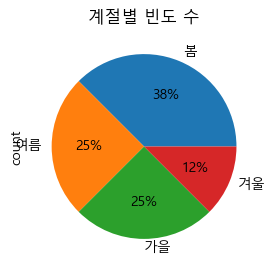

In [23]:
# 시각화 - 막대그래프, 원그래프
fd = season.value_counts()
fd.plot(
    kind='pie',
    autopct='%1.0f%%',
    figsize=(10, 3)
)
plt.title('계절별 빈도 수')
plt.show()

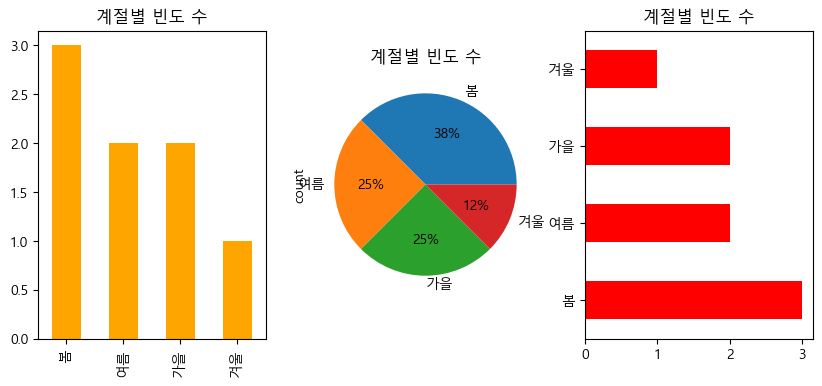

In [29]:
# 시각형 - 막대그래프, 원그래프
fig, axes = plt.subplots(1, 3, figsize=(10, 4)) # 1행 3열짜리 fig 세트를 형성

# 막대 그래프
fd.plot.bar(
    ax = axes[0],
    color=('orange'),
    title = '계절별 빈도 수'
)

# 원 그래프
fd.plot.pie(
    ax = axes[1],
    color=('midnightblue'),
    title = '계절별 빈도 수',
    autopct='%1.0f%%'
)

# barh 그래프
fd.plot.barh(
    ax = axes[2],
    color=('red'),
    title = '계절별 빈도 수'
)
plt.show()

### 2. 수치형 데이터

In [44]:
from scipy import stats

# 정상적인 몸무게 데이터
weight1 = pd.Series([60, 54, 64, 72, 86, 63, 61])

# 이상치 데이터를 추가
weight2 = pd.Series([60, 54, 64, 72, 86, 63, 61, 150])

In [50]:
# 평균값 구하기
print(f"weight1_mean : {weight1.mean():.1f}")
print(f"weight2_mean : {weight2.mean():.1f}")

# 중앙값 구하기
print(f"weight1_median : {weight1.median()}")
print(f"weight2_median : {weight2.median()}")

# 절사평균 구하기
print(f"절사평균(20%): {stats.trim_mean(weight2, 0.2):.1f}")

weight1_mean : 65.7
weight2_mean : 76.2
weight1_median : 63.0
weight2_median : 63.5
절사평균(20%): 67.7


###### 이상치가 포함된 데이터는 평균값보다 중앙값이 더 신뢰도가 높다
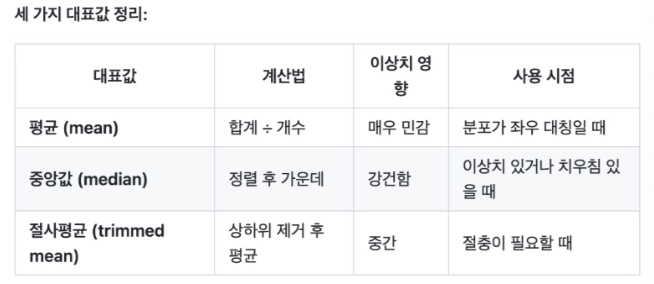

In [51]:
weight1.describe

<bound method NDFrame.describe of 0    60
1    54
2    64
3    72
4    86
5    63
6    61
dtype: int64>

In [57]:
# 분산과 표준편차
# 표준편차가 작을수록 데이터가 밀집해 있음

mydata = pd.Series([60, 62, 64, 65, 68, 69, 72])
var_result = float(mydata.var())
var_std = float(mydata.std())

print('평균 (mean):', mydata.mean())
print('분산 (var):', var_result)
print('표준편차 (std):', var_std) # 표준편차 15이상이면 평균 주위에 넓게 퍼져있음
mydata.describe()

평균 (mean): 65.71428571428571
분산 (var): 17.57142857142857
표준편차 (std): 4.191828786034631


count     7.000000
mean     65.714286
std       4.191829
min      60.000000
25%      63.000000
50%      65.000000
75%      68.500000
max      72.000000
dtype: float64

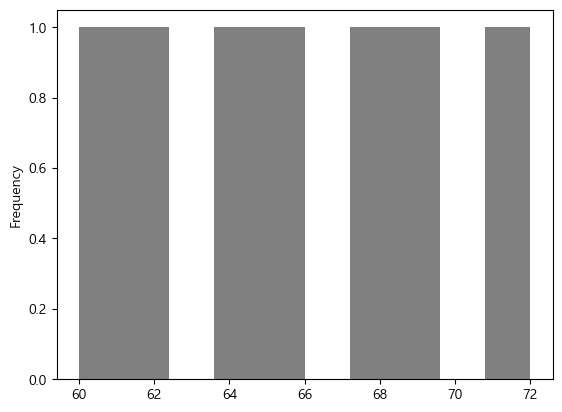

In [58]:
# 수치형 데이터의 시각화 - 히스토그램
mydata.plot(
    kind='hist',
    bins=10,
    color='gray'
)
plt.show()

- 실습데이터 준비 : iris.csv

In [60]:
iris_df = pd.read_csv('data/iris.csv')
iris_df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

In [61]:
iris_df.shape

(150, 6)

In [62]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


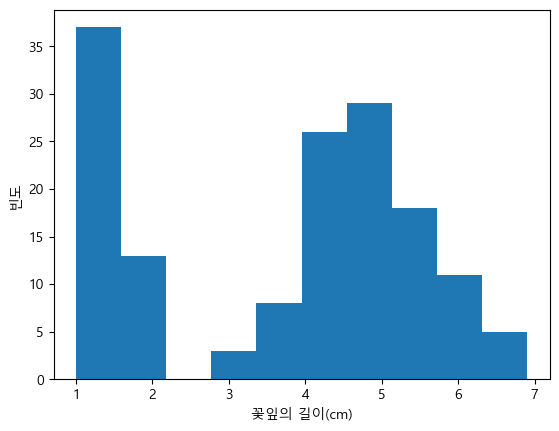

In [71]:
# 꽃잎의 길이를 통한 분포 확인 - PetalLengthCm
iris_df['PetalLengthCm'].plot(
    kind='hist',
    bins = 10
)
plt.xlabel('꽃잎의 길이(cm)')
plt.ylabel('빈도')
plt.show()

In [72]:
iris_df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [77]:
iris_df['Species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [81]:
iris_df.groupby('Species')['PetalLengthCm'].mean()

Species
Iris-setosa        1.464
Iris-versicolor    4.260
Iris-virginica     5.552
Name: PetalLengthCm, dtype: float64

- 타이타닉 데이터 셋 로드

In [83]:
# 승객의 나이가 어느 중심에 분포되어 있는가
titanic_df = pd.read_csv('data/titanic/train.csv')
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


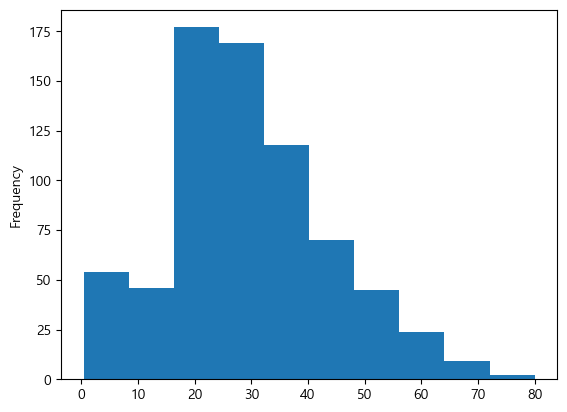

In [84]:
titanic_df['Age'].plot(
    kind='hist',
    bins = 10
)
plt.show()

In [87]:
titanic_df['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [91]:
em_dict = {
    'S': 0,
    'C': 1,
    'Q': 2
}
em_dict
titanic_df['em'] = titanic_df['Embarked'].map(em_dict)
titanic_df['em']

0      0.0
1      1.0
2      0.0
3      0.0
4      0.0
      ... 
886    0.0
887    0.0
888    0.0
889    1.0
890    2.0
Name: em, Length: 891, dtype: float64

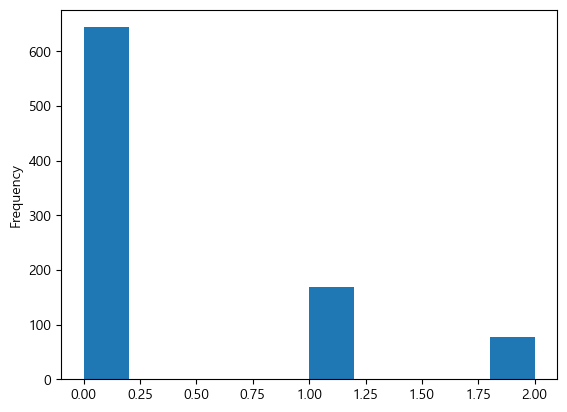

In [92]:
titanic_df['em'].plot(
    kind="hist",
    bins=10
)
plt.show()

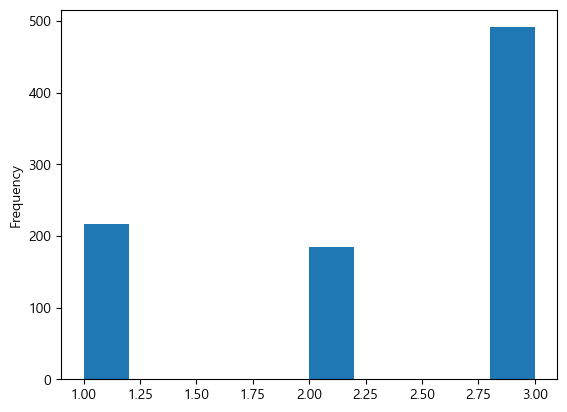

In [93]:
titanic_df['Pclass'].plot(
    kind="hist",
    bins=10
)
plt.show()

In [94]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,em
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0.0


In [96]:
titanic_df.loc[0, 'Age'] = 1000
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,em
0,1,0,3,"Braund, Mr. Owen Harris",male,1000.0,1,0,A/5 21171,7.2500,NaN,S,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0.0


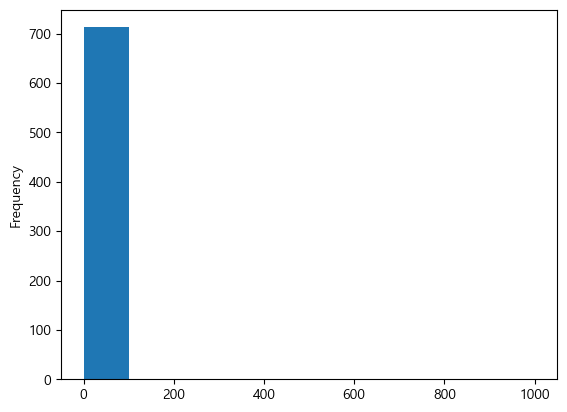

In [97]:
titanic_df['Age'].plot(
    kind='hist',
    bins = 10
)
plt.show()

In [101]:
print(f"평균값 : {titanic_df['Age'].mean()}")
print(f"중간값 : {titanic_df['Age'].median()}")
print(f"최댓값 : {titanic_df['Age'].max()}")
print(f"최솟값 : {titanic_df['Age'].min()}")

평균값 : 31.068865546218486
중간값 : 28.0
최댓값 : 1000.0
최솟값 : 0.42
